# Customer Churn Prediction Using Support Vector Machine (SVM)

## Introduction

Customer churn occurs when a customer stops using a company's products or services. For subscription-based businesses such as telecommunications companies, understanding and predicting customer churn is important for improving customer retention and supporting data-driven business decisions.

This project uses the **Telco Customer Churn dataset**, which contains information about customers' demographic characteristics, services, account details, contract information, and billing details. The target variable, **Churn**, indicates whether a customer has left the company.

The project aims to develop a **machine learning classification model using Support Vector Machine (SVM)** to predict whether a customer is likely to churn or remain with the company.

## Problem Statement

The objective is to use customer-related information to classify customers into two categories:

* **Churn = Yes** — the customer has left the company.
* **Churn = No** — the customer has remained with the company.

## Project Objectives

The key objectives of this project are to:

* Understand and analyze the customer churn dataset.
* Perform data cleaning and preprocessing.
* Explore patterns and relationships associated with customer churn.
* Transform categorical variables into a suitable format for machine learning.
* Apply feature scaling where required for SVM.
* Build an SVM classification model for churn prediction.
* Compare different SVM kernels and optimize model hyperparameters.
* Evaluate model performance using appropriate classification metrics.
* Develop a model that can support customer retention and data-driven decision-making.

## Expected Outcome

The expected outcome is a trained and evaluated **SVM classification model** capable of predicting customer churn based on the available customer, service, contract, and billing information.


## A). Data Cleaning

## 1). Import Required Libraries

The following Python libraries are used for data manipulation, visualization, statistical analysis, and machine learning. Each library provides specific functionality required throughout the customer churn prediction workflow.

#### What is GridSearchCV?
- GridSearchCV is a technique from Scikit-learn used to find the best combination of model hyperparameters.
- For SVM, important hyperparameters include:
    - C
    - kernel
    - gamma

#### ROC-AUC Score
- ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) is an evaluation metric used to measure how well a classification model distinguishes between two classes. It ranges from 0 to 1, where a higher score generally indicates better ability to separate the classes.
- For my project, it measures how well the SVM model distinguishes between customers who churn and customers who do not churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## 2). Load the Dataset

The Telco Customer Churn dataset is loaded into a pandas DataFrame. The dataset contains customer demographic information, subscribed services, contract details, billing information, and the customer's churn status.


In [2]:
data = pd.read_csv(r"Data/Telco Customer Dataset.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
data.shape

(7043, 21)

In [8]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 3). Dataset Column Description

The dataset contains **21 columns** representing customer demographics, services, account information, billing details, and churn status.

| No. | Column             | Description                                                                                  |
| --: | ------------------ | -------------------------------------------------------------------------------------------- |
|   1 | `customerID`       | Unique identification number assigned to each customer.                                      |
|   2 | `gender`           | Gender of the customer.                                                                      |
|   3 | `SeniorCitizen`    | Indicates whether the customer is a senior citizen (`1` = Yes, `0` = No).                    |
|   4 | `Partner`          | Indicates whether the customer has a partner.                                                |
|   5 | `Dependents`       | Indicates whether the customer has dependents.                                               |
|   6 | `tenure`           | Number of months the customer has been with the company.                                     |
|   7 | `PhoneService`     | Indicates whether the customer has phone service.                                            |
|   8 | `MultipleLines`    | Indicates whether the customer has multiple phone lines, a single line, or no phone service. |
|   9 | `InternetService`  | Type of internet service used by the customer.                                               |
|  10 | `OnlineSecurity`   | Indicates whether the customer has online security service.                                  |
|  11 | `OnlineBackup`     | Indicates whether the customer has online backup service.                                    |
|  12 | `DeviceProtection` | Indicates whether the customer has device protection service.                                |
|  13 | `TechSupport`      | Indicates whether the customer has technical support service.                                |
|  14 | `StreamingTV`      | Indicates whether the customer has TV streaming service.                                     |
|  15 | `StreamingMovies`  | Indicates whether the customer has movie streaming service.                                  |
|  16 | `Contract`         | Type of contract selected by the customer.                                                   |
|  17 | `PaperlessBilling` | Indicates whether the customer uses paperless billing.                                       |
|  18 | `PaymentMethod`    | Payment method used by the customer.                                                         |
|  19 | `MonthlyCharges`   | Amount charged to the customer each month.                                                   |
|  20 | `TotalCharges`     | Total amount charged to the customer during their period with the company.                   |
|  21 | `Churn`            | Target variable indicating whether the customer left the company (`Yes`) or stayed (`No`).   |

### Feature Categories

The columns can be broadly categorized into:

* **Customer Information:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`
* **Service Information:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
* **Account & Billing Information:** `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
* **Target Variable:** `Churn`
* **Customer Identifier:** `customerID`


### Dataset Overview and Missing Values

The dataset contains **7,043 rows and 21 columns** with **no duplicate records**. The `TotalCharges` column contains **11 missing values**, which need to be handled during the data-cleaning stage.

The target variable, `Churn`, contains two classes:

* **No:** 5,174 customers
* **Yes:** 1,869 customers

This shows that the dataset contains more customers who did not churn than customers who churned. The class distribution will be considered during model training and evaluation.


In [9]:
data[data['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
data.loc[
    data['TotalCharges'].isnull(),
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [11]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [12]:
data['TotalCharges'].isnull().sum()

np.int64(0)

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
data.to_csv(r"Data/Telco Customer Dataset Cleaned.csv", index=False)

### Handling Missing Values

The `TotalCharges` column initially contained **11 missing values**. On investigating these records, all 11 customers were found to have a `tenure` of **0 months**, indicating that they were new customers. Since they had not yet accumulated any charges, the missing `TotalCharges` values were replaced with **0**.

After this treatment, the `TotalCharges` column contains **no missing values**.

### Data Type Check

The dataset was checked for appropriate data types. Numerical variables such as `SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges` are stored in numerical formats, while categorical variables such as `gender`, `Partner`, `Contract`, and `Churn` are stored as strings. The data types were found to be appropriate for further analysis and preprocessing.


## B). Exploratory Data Analysis (EDA)

In [15]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Descriptive Statistics

The descriptive statistics provide an overview of the numerical variables in the dataset. The dataset contains **7,043 observations** with no missing values in these numerical columns after data cleaning.

* **SeniorCitizen:** About **16.2%** of customers are senior citizens, since the mean is 0.162.
* **Tenure:** Customers have an average tenure of approximately **32.37 months**, with values ranging from 0 to 72 months.
* **MonthlyCharges:** The average monthly charge is approximately **64.76**, with charges ranging from **18.25 to 118.75**.
* **TotalCharges:** The average total charge is approximately **2,279.73**, ranging from **0 to 8,684.80**.

The median values indicate that half of the customers have a tenure of **29 months or less**, monthly charges of **70.35 or less**, and total charges of **1,394.55 or less**.


In [16]:
data['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Churn Distribution

The target variable `Churn` contains two classes: `No` and `Yes`. There are **5,174 customers who did not churn (73.46%)** and **1,869 customers who churned (26.54%)**. This indicates that the target variable is somewhat imbalanced, with non-churned customers representing the majority class.


## 1). Churn Distribution Visualization

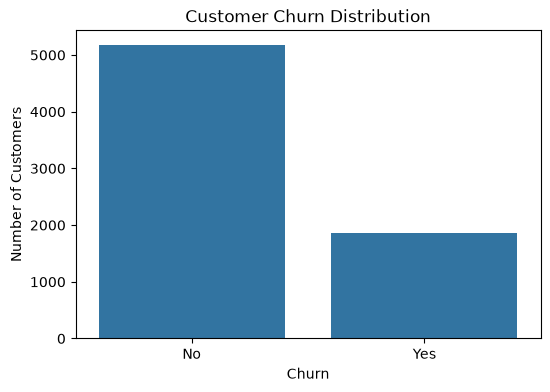

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

#### **Observation:**
The dataset contains more customers who did not churn than customers who churned. There are 5,174 customers who stayed with the company and 1,869 customers who churned. This indicates an imbalance in the target variable, which should be considered during model evaluation.


## 2). Churn Analysis by Contract Type

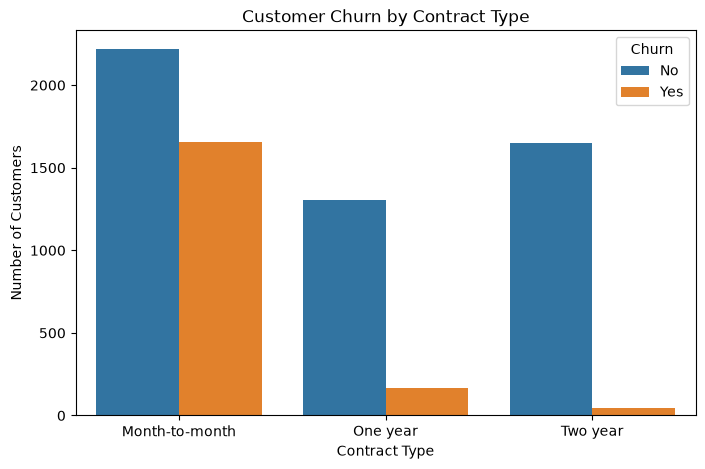

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data, x='Contract', hue='Churn')

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

#### **Observation:**
Month-to-month contract customers account for the largest number of churned customers. Customers with one-year and two-year contracts have considerably fewer churned customers. This indicates that contract type may provide useful information for predicting customer churn.


## 3). Churn Analysis by Internet Service

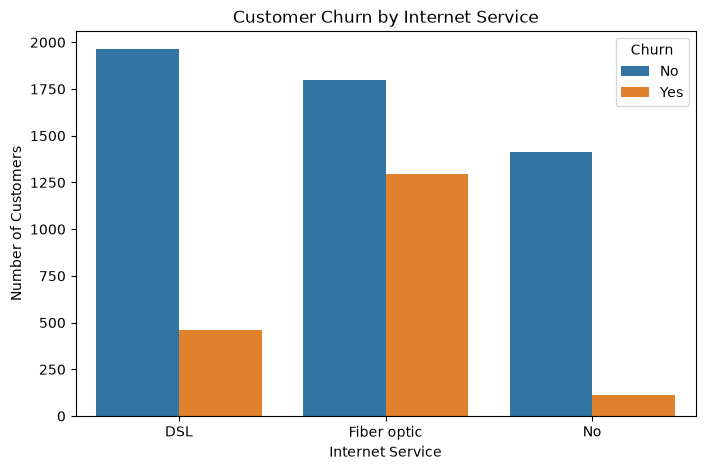

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data, x='InternetService', hue='Churn')

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

#### **Observation:** 
Fiber optic customers have the highest number of churned customers among the internet service categories, followed by DSL customers. Customers without internet service have comparatively fewer churned customers. This indicates that internet service type may be an important feature for churn prediction.


## 4). Churn Analysis by Payment Method

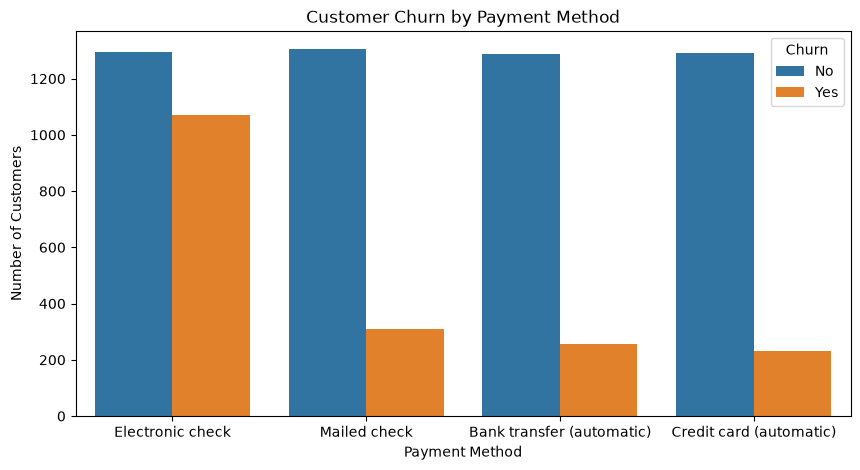

In [20]:
plt.figure(figsize=(10, 5))

sns.countplot(data=data, x='PaymentMethod', hue='Churn')

plt.title('Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

#### **Observation:** 
Electronic check customers have the highest number of churned customers among the payment methods shown. Mailed check, bank transfer (automatic), and credit card (automatic) customers have comparatively fewer churned customers. This indicates that payment method may provide useful information for analyzing and predicting customer churn.


## 5). Tenure vs Churn

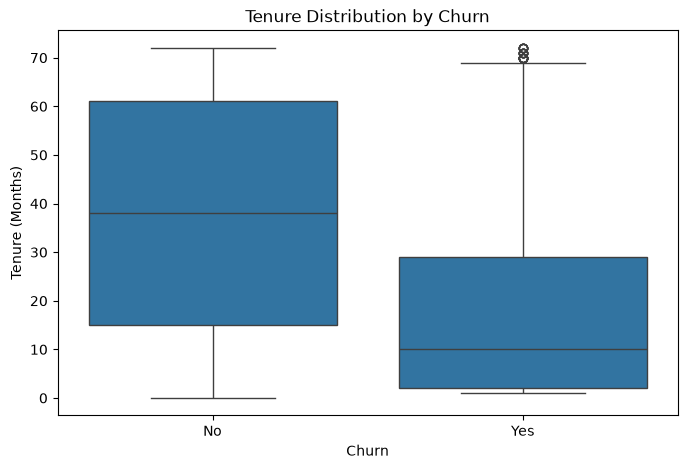

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=data, x='Churn', y='tenure')

plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

#### **Observation:**
Customers who churned generally have shorter tenure compared with customers who remained with the company. This indicates that tenure may be an important feature for predicting customer churn.

## 6). Monthly Charges vs Churn

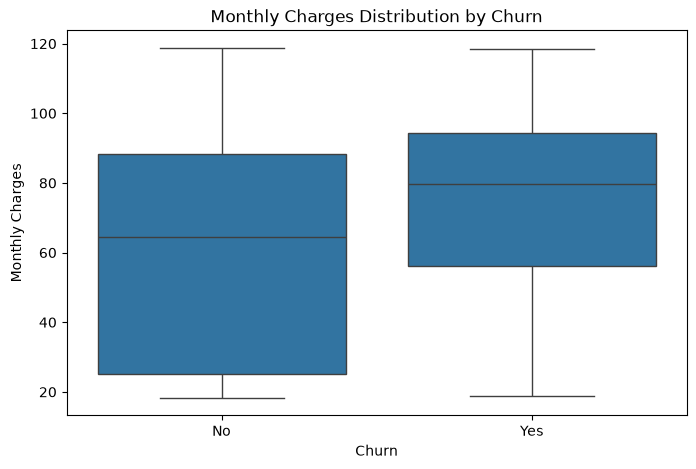

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=data, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

#### **Observation:**
Customers who churned generally have higher monthly charges compared with customers who did not churn. This suggests that `MonthlyCharges` may provide useful information for predicting customer churn.

## 7). Total Charges vs Churn

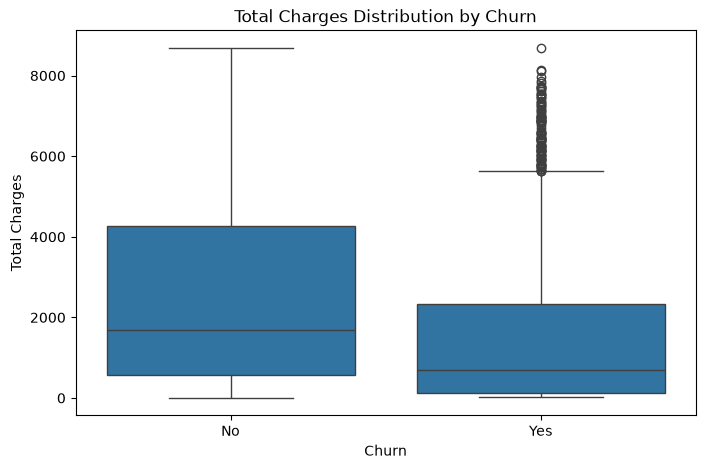

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=data, x='Churn', y='TotalCharges')

plt.title('Total Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

#### **Observation:** 
Customers who did not churn generally show higher total charges than customers who churned. This may be related to their longer tenure with the company, since total charges accumulate over time.

## Key EDA Findings

The exploratory data analysis provided the following key observations:

* The dataset contains **7,043 customers**, with more customers not churning than churning, indicating an imbalance in the target variable.
* **Month-to-month contract customers** account for the largest number of churned customers compared with one-year and two-year contract customers.
* **Fiber optic customers** show a relatively high number of churned customers compared with other internet service categories.
* **Electronic check** is associated with the highest number of churned customers among the payment methods analyzed.
* Customers who churned generally have **shorter tenure** compared with customers who did not churn.
* Customers who churned generally show **higher monthly charges** than customers who did not churn.
* Customers who did not churn generally have **higher total charges**, which may be related to their longer tenure with the company.
* These patterns indicate that **contract type, internet service, payment method, tenure, monthly charges, and total charges** may provide useful information for predicting customer churn.

These observations will guide the feature preprocessing and SVM modeling stages of the project.
